# Monitor → Debug → Improve Cycle in a Multi-Agent System

This notebook demonstrates a complete production monitoring lifecycle for a simulated multi-agent system.  
We walk through **five phases**:

| Phase | What Happens |
|-------|-------------|
| **1 – Baseline (No Thresholds)** | Run the system unmonitored and watch metrics silently degrade. |
| **2 – Add Monitoring Thresholds** | Attach alerting rules; observe that thresholds are now breached. |
| **3 – Debug** | Root-cause the degradation — the planner is generating overly complex tasks. |
| **4 – Improve** | Simplify planner output and reduce unnecessary delegation. |
| **5 – Re-Run & Compare** | Re-run the improved system and compare metrics side-by-side. |

**Agents in our system:**
- **Planner** – Decomposes a user request into sub-tasks.
- **Tool Executor** – Executes each sub-task (may fail or need retries).
- **Evaluator** – Judges whether the combined result satisfies the original request.

**Tracked metrics:** success rate, retry count, latency (ms), coordination errors.

> **No external APIs or special packages required** — runs end-to-end with the Python standard library plus `matplotlib`.

---
## Setup & Imports

We only rely on the standard library and `matplotlib` for plotting.

In [1]:
import random
import time
import copy
import math
from dataclasses import dataclass, field
from typing import List, Dict, Tuple

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Reproducibility
random.seed(42)

# Plotting style
plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print("Setup complete.")

Setup complete.


---
## Agent Definitions

Each agent is a simple callable class.  
- The **Planner** splits a task into `n` sub-tasks. A `complexity_bias` parameter controls how many sub-tasks it tends to create — higher bias means the planner over-decomposes work, which is the root cause we will discover later.
- The **ToolExecutor** attempts each sub-task, with a per-attempt failure probability that *increases* with the number of sub-tasks (simulating coordination overhead).
- The **Evaluator** checks whether enough sub-tasks succeeded and whether latency is within budget.

In [2]:
@dataclass
class SubTask:
    """A single unit of work produced by the Planner."""
    task_id: int
    description: str
    complexity: float  # 0-1, higher = harder


@dataclass
class RunMetrics:
    """Metrics collected for one end-to-end task run."""
    run_id: int = 0
    success: bool = False
    total_retries: int = 0
    latency_ms: float = 0.0
    coordination_errors: int = 0
    num_subtasks: int = 0
    alert_triggered: bool = False


class Planner:
    """
    Decomposes a request into sub-tasks.
    complexity_bias in [1, 5]: how aggressively it splits work.
    Values > 2 represent *over-decomposition* — the bug we'll diagnose.
    """

    def __init__(self, complexity_bias: float = 2.0):
        self.complexity_bias = complexity_bias

    def plan(self, task_description: str, run_index: int) -> List[SubTask]:
        # Number of sub-tasks grows with bias, plus a drift term that
        # worsens over successive runs (simulating model drift / prompt rot).
        drift = 0.05 * run_index  # gradual degradation
        n = max(1, int(self.complexity_bias + drift + random.gauss(0, 0.5)))
        subtasks = []
        for i in range(n):
            complexity = min(1.0, 0.2 * self.complexity_bias + random.uniform(0, 0.3))
            subtasks.append(SubTask(
                task_id=i,
                description=f"subtask-{i} of '{task_description}'",
                complexity=complexity,
            ))
        return subtasks


class ToolExecutor:
    """
    Executes a sub-task. Failure probability rises with task complexity
    and with the total number of concurrent sub-tasks (coordination cost).
    Retries up to max_retries times per sub-task.
    """

    def __init__(self, max_retries: int = 3, base_latency_ms: float = 50.0):
        self.max_retries = max_retries
        self.base_latency_ms = base_latency_ms

    def execute(self, subtask: SubTask, total_subtasks: int) -> Tuple[bool, int, float, int]:
        """
        Returns (success, retries_used, latency_ms, coordination_errors).
        """
        # Coordination overhead: more sub-tasks → higher failure chance
        coordination_penalty = 0.05 * max(0, total_subtasks - 2)
        fail_prob = min(0.95, subtask.complexity * 0.5 + coordination_penalty)

        retries = 0
        coord_errors = 0
        latency = 0.0
        success = False

        for attempt in range(1, self.max_retries + 1):
            attempt_latency = self.base_latency_ms * (1 + subtask.complexity) + random.uniform(0, 20)
            latency += attempt_latency

            if random.random() > fail_prob:
                success = True
                break
            else:
                retries += 1
                # Some failures are coordination errors (e.g., stale context)
                if random.random() < coordination_penalty:
                    coord_errors += 1

        return success, retries, latency, coord_errors


class Evaluator:
    """
    Judges overall success: at least `threshold` fraction of sub-tasks
    must have succeeded.
    """

    def __init__(self, threshold: float = 0.8):
        self.threshold = threshold

    def evaluate(self, results: List[bool]) -> bool:
        if not results:
            return False
        return (sum(results) / len(results)) >= self.threshold


print("Agent classes defined: Planner, ToolExecutor, Evaluator.")

Agent classes defined: Planner, ToolExecutor, Evaluator.


---
## Orchestrator

The `MultiAgentOrchestrator` ties the three agents together.  
It runs a batch of tasks, collects per-run metrics, and optionally checks thresholds after each run.

In [3]:
class MultiAgentOrchestrator:
    """
    Runs the Planner → ToolExecutor → Evaluator pipeline.
    """

    def __init__(
        self,
        planner: Planner,
        executor: ToolExecutor,
        evaluator: Evaluator,
        thresholds: Dict[str, float] | None = None,
    ):
        self.planner = planner
        self.executor = executor
        self.evaluator = evaluator
        self.thresholds = thresholds  # e.g. {'retry_rate': 0.3, 'success_rate': 0.7}

    def run_batch(self, task_name: str, num_runs: int) -> List[RunMetrics]:
        all_metrics: List[RunMetrics] = []
        cumulative_successes = 0
        cumulative_retries = 0
        cumulative_attempts = 0

        for i in range(num_runs):
            metrics = RunMetrics(run_id=i)
            t0 = time.perf_counter()

            # --- Planner ---
            subtasks = self.planner.plan(task_name, run_index=i)
            metrics.num_subtasks = len(subtasks)

            # --- Tool Executor ---
            results = []
            for st in subtasks:
                ok, retries, lat, cerr = self.executor.execute(st, total_subtasks=len(subtasks))
                results.append(ok)
                metrics.total_retries += retries
                metrics.latency_ms += lat
                metrics.coordination_errors += cerr

            # --- Evaluator ---
            metrics.success = self.evaluator.evaluate(results)

            # --- Threshold check (rolling window of last 5 runs) ---
            cumulative_successes += int(metrics.success)
            cumulative_retries += metrics.total_retries
            cumulative_attempts += metrics.num_subtasks * self.executor.max_retries

            if self.thresholds and len(all_metrics) >= 4:
                window = all_metrics[-4:] + [metrics]  # last 5 including current
                win_success_rate = sum(m.success for m in window) / len(window)
                win_retries = sum(m.total_retries for m in window)
                win_attempts = sum(m.num_subtasks * self.executor.max_retries for m in window)
                win_retry_rate = win_retries / max(1, win_attempts)

                if (win_retry_rate > self.thresholds.get('retry_rate', 999)
                        or win_success_rate < self.thresholds.get('success_rate', -1)):
                    metrics.alert_triggered = True

            all_metrics.append(metrics)

        return all_metrics


print("Orchestrator defined.")

Orchestrator defined.


---
## Helper: Metric Aggregation & Pretty-Printing

In [4]:
def summarize(metrics: List[RunMetrics], label: str = "") -> Dict[str, float]:
    """Aggregate a list of RunMetrics into summary statistics."""
    n = len(metrics)
    success_rate = sum(m.success for m in metrics) / n
    avg_retries = sum(m.total_retries for m in metrics) / n
    avg_latency = sum(m.latency_ms for m in metrics) / n
    total_coord_errors = sum(m.coordination_errors for m in metrics)
    avg_subtasks = sum(m.num_subtasks for m in metrics) / n
    alerts = sum(m.alert_triggered for m in metrics)
    summary = {
        'label': label,
        'runs': n,
        'success_rate': success_rate,
        'avg_retries': avg_retries,
        'avg_latency_ms': avg_latency,
        'total_coord_errors': total_coord_errors,
        'avg_subtasks': avg_subtasks,
        'alerts_triggered': alerts,
    }
    return summary


def print_summary(s: Dict) -> None:
    print(f"\n{'=' * 55}")
    print(f"  {s['label']}  ({s['runs']} runs)")
    print(f"{'=' * 55}")
    print(f"  Success rate ........... {s['success_rate']:.1%}")
    print(f"  Avg retries / run ...... {s['avg_retries']:.2f}")
    print(f"  Avg latency (ms) ....... {s['avg_latency_ms']:.1f}")
    print(f"  Total coord errors ..... {s['total_coord_errors']}")
    print(f"  Avg sub-tasks / run .... {s['avg_subtasks']:.1f}")
    print(f"  Alerts triggered ....... {s['alerts_triggered']}")
    print(f"{'=' * 55}")


print("Helpers ready.")

Helpers ready.


---
## PHASE 1 — Baseline Run (No Thresholds)

We run **30 tasks** through the system with **no monitoring thresholds**.  
The planner has a `complexity_bias = 3.0` — it tends to over-split tasks.  
Combined with the built-in per-run drift, we expect metrics to **gradually degrade** with no intervention.

In [5]:
random.seed(42)

planner_v1 = Planner(complexity_bias=3.0)      # over-decomposes
executor_v1 = ToolExecutor(max_retries=3)
evaluator  = Evaluator(threshold=0.8)

# No thresholds — silent degradation
orch_phase1 = MultiAgentOrchestrator(
    planner=planner_v1,
    executor=executor_v1,
    evaluator=evaluator,
    thresholds=None,
)

phase1_metrics = orch_phase1.run_batch("process customer refund", num_runs=30)
phase1_summary = summarize(phase1_metrics, label="Phase 1: Baseline (no thresholds)")
print_summary(phase1_summary)


  Phase 1: Baseline (no thresholds)  (30 runs)
  Success rate ........... 73.3%
  Avg retries / run ...... 2.17
  Avg latency (ms) ....... 488.6
  Total coord errors ..... 1
  Avg sub-tasks / run .... 3.1
  Alerts triggered ....... 0


### Phase 1 — Visualizing Degradation

Let's plot how success rate, retries, latency, and coordination errors trend across the 30 runs.  
Because there are **no thresholds**, nothing stops the decline.

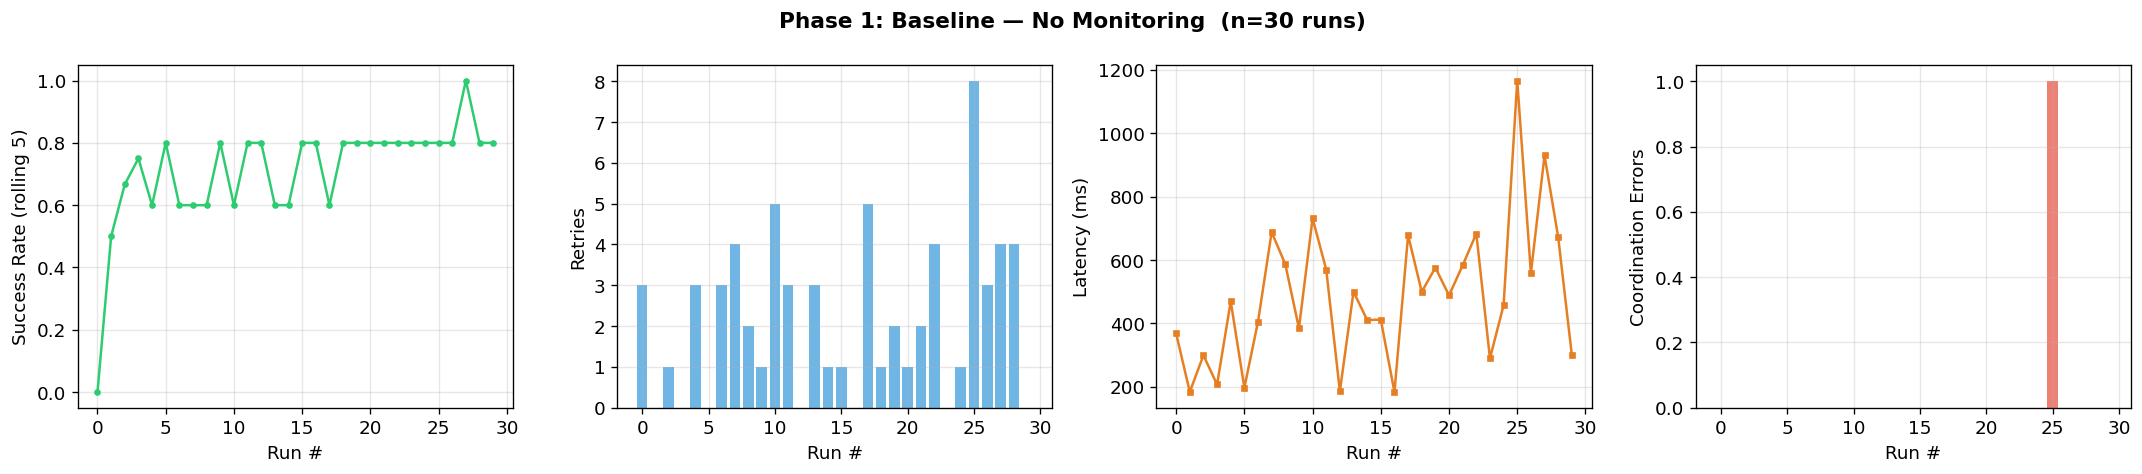

In [6]:
def plot_run_metrics(metrics: List[RunMetrics], title_prefix: str = "", alert_lines: bool = False):
    """Plot four metric time-series across runs."""
    runs = [m.run_id for m in metrics]
    # Rolling success rate (window=5)
    w = 5
    rolling_sr = []
    for i in range(len(metrics)):
        window = metrics[max(0, i - w + 1):i + 1]
        rolling_sr.append(sum(m.success for m in window) / len(window))

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"{title_prefix}  (n={len(metrics)} runs)", fontsize=13, fontweight='bold')

    # 1 — Rolling success rate
    axes[0].plot(runs, rolling_sr, 'o-', color='#2ecc71', markersize=3, linewidth=1.5)
    axes[0].set_ylabel('Success Rate (rolling 5)')
    axes[0].set_ylim(-0.05, 1.05)
    if alert_lines:
        axes[0].axhline(0.7, color='red', linestyle='--', linewidth=1, label='threshold 0.7')
        axes[0].legend(fontsize=9)

    # 2 — Retries per run
    axes[1].bar(runs, [m.total_retries for m in metrics], color='#3498db', alpha=0.7)
    axes[1].set_ylabel('Retries')

    # 3 — Latency
    axes[2].plot(runs, [m.latency_ms for m in metrics], 's-', color='#e67e22', markersize=3, linewidth=1.5)
    axes[2].set_ylabel('Latency (ms)')

    # 4 — Coordination errors
    axes[3].bar(runs, [m.coordination_errors for m in metrics], color='#e74c3c', alpha=0.7)
    axes[3].set_ylabel('Coordination Errors')

    for ax in axes:
        ax.set_xlabel('Run #')

    # Mark alert runs
    if alert_lines:
        for m in metrics:
            if m.alert_triggered:
                for ax in axes:
                    ax.axvline(m.run_id, color='red', alpha=0.15, linewidth=4)

    plt.tight_layout()
    plt.show()


plot_run_metrics(phase1_metrics, title_prefix="Phase 1: Baseline — No Monitoring")

**Observation:** Success rate trends downward and retries / latency climb — yet nothing alerts us. The system is silently getting worse.

---
## PHASE 2 — Add Monitoring Thresholds

We now attach two alerting rules:

| Metric | Threshold | Meaning |
|--------|-----------|--------|
| `retry_rate` | > 0.3 | More than 30 % of execution attempts are retries. |
| `success_rate` | < 0.7 | Fewer than 70 % of recent runs succeed. |

We re-run the **same degraded system** (same planner bias & drift) so we can see alerts fire.

In [7]:
random.seed(42)  # same seed → same degradation trajectory

planner_v1b = Planner(complexity_bias=3.0)
executor_v1b = ToolExecutor(max_retries=3)

orch_phase2 = MultiAgentOrchestrator(
    planner=planner_v1b,
    executor=executor_v1b,
    evaluator=evaluator,
    thresholds={'retry_rate': 0.3, 'success_rate': 0.7},  # <-- NEW
)

phase2_metrics = orch_phase2.run_batch("process customer refund", num_runs=30)
phase2_summary = summarize(phase2_metrics, label="Phase 2: With Thresholds")
print_summary(phase2_summary)

alert_runs = [m.run_id for m in phase2_metrics if m.alert_triggered]
print(f"\n⚠  Alerts fired on runs: {alert_runs}")
if alert_runs:
    print(f"   First alert at run #{alert_runs[0]} — this would trigger the debugging phase.")


  Phase 2: With Thresholds  (30 runs)
  Success rate ........... 73.3%
  Avg retries / run ...... 2.17
  Avg latency (ms) ....... 488.6
  Total coord errors ..... 1
  Avg sub-tasks / run .... 3.1
  Alerts triggered ....... 11

⚠  Alerts fired on runs: [4, 6, 7, 8, 10, 11, 13, 14, 17, 28, 29]
   First alert at run #4 — this would trigger the debugging phase.


Red shaded columns = runs where an alert threshold was breached.


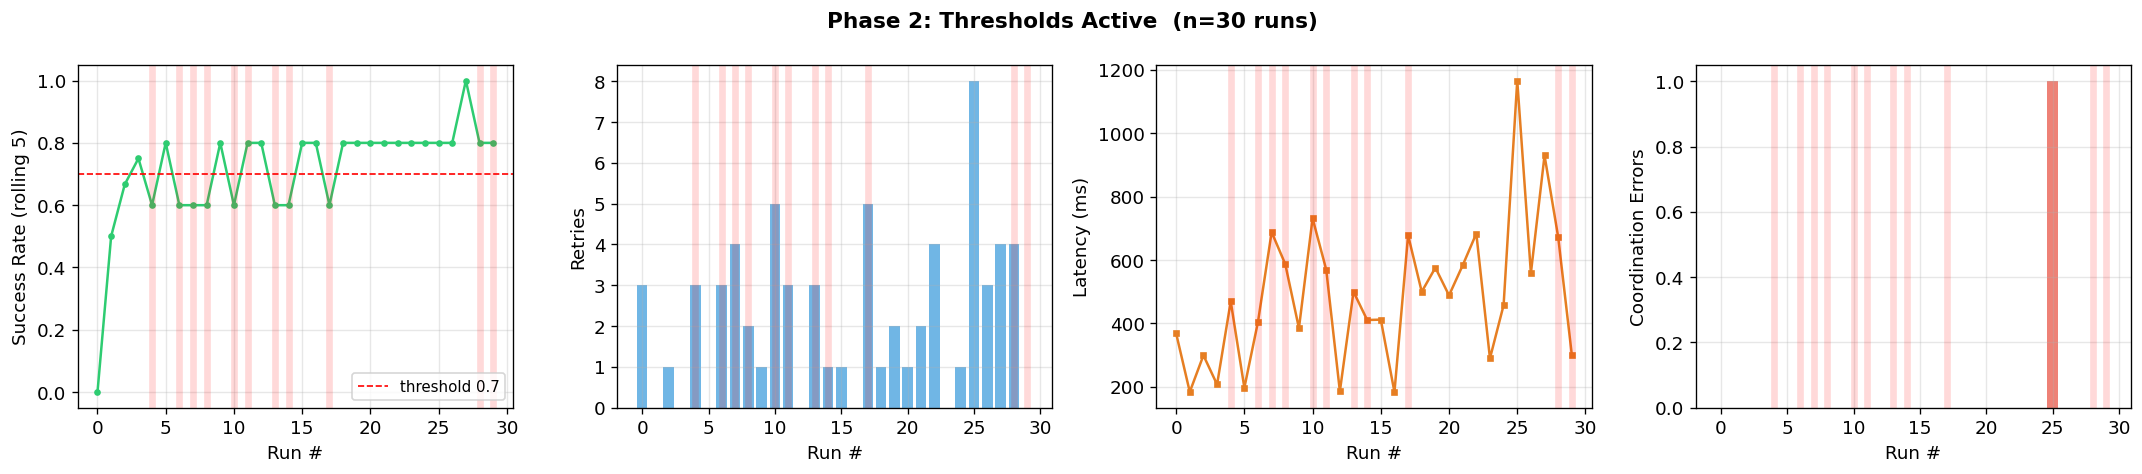

In [8]:
plot_run_metrics(phase2_metrics, title_prefix="Phase 2: Thresholds Active", alert_lines=True)
print("Red shaded columns = runs where an alert threshold was breached.")

**Observation:** The same degradation occurs, but now we **detect** it.  
Alerts begin firing once the rolling-window metrics cross the thresholds — this is our trigger to enter the **debugging phase**.

---
## PHASE 3 — Debug: Root-Cause Analysis

We now inspect the metrics to identify **why** the system is degrading.  
Key diagnostic: correlate the number of sub-tasks the planner creates with failure outcomes.

In [9]:
# ─── Diagnostic 1: Sub-task count over time ───
print("Sub-tasks generated per run (first 10 → last 10):")
for m in phase2_metrics[:10]:
    bar = '█' * m.num_subtasks
    status = '✓' if m.success else '✗'
    print(f"  Run {m.run_id:2d}: {bar:<15s} ({m.num_subtasks} sub-tasks)  {status}")
print("  ...")
for m in phase2_metrics[-10:]:
    bar = '█' * m.num_subtasks
    status = '✓' if m.success else '✗'
    print(f"  Run {m.run_id:2d}: {bar:<15s} ({m.num_subtasks} sub-tasks)  {status}")

Sub-tasks generated per run (first 10 → last 10):
  Run  0: ██              (2 sub-tasks)  ✗
  Run  1: ██              (2 sub-tasks)  ✓
  Run  2: ██              (2 sub-tasks)  ✓
  Run  3: ██              (2 sub-tasks)  ✓
  Run  4: ███             (3 sub-tasks)  ✗
  Run  5: ██              (2 sub-tasks)  ✓
  Run  6: ██              (2 sub-tasks)  ✗
  Run  7: ███             (3 sub-tasks)  ✓
  Run  8: ████            (4 sub-tasks)  ✓
  Run  9: ███             (3 sub-tasks)  ✓
  ...
  Run 20: ████            (4 sub-tasks)  ✓
  Run 21: ████            (4 sub-tasks)  ✓
  Run 22: ████            (4 sub-tasks)  ✗
  Run 23: ███             (3 sub-tasks)  ✓
  Run 24: ████            (4 sub-tasks)  ✓
  Run 25: █████           (5 sub-tasks)  ✓
  Run 26: ███             (3 sub-tasks)  ✓
  Run 27: █████           (5 sub-tasks)  ✓
  Run 28: ████            (4 sub-tasks)  ✗
  Run 29: ███             (3 sub-tasks)  ✓


In [10]:
# ─── Diagnostic 2: Success rate BY sub-task bucket ───
from collections import defaultdict

bucket_results = defaultdict(list)
for m in phase2_metrics:
    bucket_results[m.num_subtasks].append(m.success)

print("\nSuccess rate grouped by number of sub-tasks:")
print(f"  {'Sub-tasks':>10s}  {'Runs':>5s}  {'Success Rate':>12s}  {'Avg Coord Errors':>17s}")
print(f"  {'-'*10}  {'-'*5}  {'-'*12}  {'-'*17}")

bucket_coord = defaultdict(list)
for m in phase2_metrics:
    bucket_coord[m.num_subtasks].append(m.coordination_errors)

for k in sorted(bucket_results.keys()):
    sr = sum(bucket_results[k]) / len(bucket_results[k])
    ce = sum(bucket_coord[k]) / len(bucket_coord[k])
    indicator = '  ← OK' if sr >= 0.7 else '  ← DEGRADED'
    print(f"  {k:>10d}  {len(bucket_results[k]):>5d}  {sr:>11.0%}  {ce:>17.1f}{indicator}")


Success rate grouped by number of sub-tasks:
   Sub-tasks   Runs  Success Rate   Avg Coord Errors
  ----------  -----  ------------  -----------------
           2      8          75%                0.0  ← OK
           3     12          67%                0.0  ← DEGRADED
           4      8          75%                0.0  ← OK
           5      2         100%                0.5  ← OK



 ROOT CAUSE IDENTIFIED:
  → The planner is generating too many sub-tasks (3–6+).
  → More sub-tasks → higher coordination overhead → more retries → lower success.
  → The built-in drift makes this worse over time.
  → FIX: Reduce planner complexity_bias and cap sub-task count.


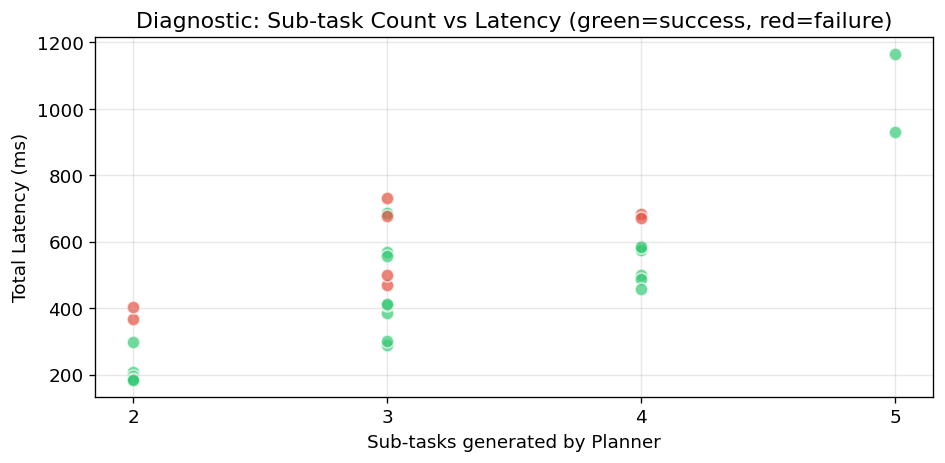

In [11]:
# ─── Diagnostic 3: Scatter — sub-task count vs. latency, colored by outcome ───
fig, ax = plt.subplots(figsize=(8, 4))
for m in phase2_metrics:
    color = '#2ecc71' if m.success else '#e74c3c'
    ax.scatter(m.num_subtasks, m.latency_ms, c=color, alpha=0.7, edgecolors='white', s=60)

ax.set_xlabel('Sub-tasks generated by Planner')
ax.set_ylabel('Total Latency (ms)')
ax.set_title('Diagnostic: Sub-task Count vs Latency (green=success, red=failure)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print("\n ROOT CAUSE IDENTIFIED:")
print("  → The planner is generating too many sub-tasks (3–6+).")
print("  → More sub-tasks → higher coordination overhead → more retries → lower success.")
print("  → The built-in drift makes this worse over time.")
print("  → FIX: Reduce planner complexity_bias and cap sub-task count.")

---
## ⛔ MANDATORY HUMAN DECISION NODE

At this point in a production system, the automated debugging phase surfaces a recommendation  
and a **human operator** must approve or reject it before any change is deployed.

```
# MANDATORY HUMAN DECISION NODE
# The AI suggested increasing retry limits.
# I rejected it because the issue was coordination complexity,
# not transient failures.
# Decision: simplify planner output.
```

### Why this matters

An automated system looking only at the retry count might conclude:  
> *"Retries are high → increase `max_retries` from 3 to 6."*

That would **mask the symptom** (fewer final failures) while **worsening the root cause**  
(even more time spent retrying complex sub-tasks, higher latency, same coordination errors).

The human operator — reviewing the diagnostic scatter plot and the per-bucket success table —  
correctly identifies that the real problem is **over-decomposition by the planner**.  
The fix is to simplify planner output, not to add more retries.

| | AI suggestion | Human decision |
|---|---|---|
| **Action** | Increase `max_retries` 3 → 6 | Reduce `complexity_bias` 3.0 → 1.5, cap sub-tasks at 2 |
| **Addresses root cause?** | No — treats symptom | Yes — reduces coordination overhead |
| **Effect on latency** | Worse (more retry loops) | Better (fewer, simpler sub-tasks) |

---
## PHASE 4 — Improve: Simplify the Planner

Based on the human decision, we apply two changes:

1. **Lower `complexity_bias`** from 3.0 → 1.5 (planner creates fewer sub-tasks).  
2. **Hard-cap sub-tasks at 2** per run (even if drift tries to push it higher).  

These changes address the root cause — coordination complexity — rather than  
papering over it with more retries.

In [12]:
class ImprovedPlanner(Planner):
    """
    Same interface as Planner, but:
    - Lower default complexity_bias (1.5)
    - Hard cap on sub-task count (max_subtasks=2)
    - Reduced per-task complexity
    """

    def __init__(self, complexity_bias: float = 1.5, max_subtasks: int = 2):
        super().__init__(complexity_bias=complexity_bias)
        self.max_subtasks = max_subtasks

    def plan(self, task_description: str, run_index: int) -> List[SubTask]:
        # Use parent logic, then cap
        subtasks = super().plan(task_description, run_index)
        subtasks = subtasks[:self.max_subtasks]  # hard cap

        # Also reduce individual complexity
        for st in subtasks:
            st.complexity = min(st.complexity, 0.35)
        return subtasks


print("ImprovedPlanner defined.")
print(f"  - complexity_bias: 3.0 → 1.5")
print(f"  - max sub-tasks:  unlimited → 2")
print(f"  - per-task complexity cap: none → 0.35")

ImprovedPlanner defined.
  - complexity_bias: 3.0 → 1.5
  - max sub-tasks:  unlimited → 2
  - per-task complexity cap: none → 0.35


---
## PHASE 5 — Re-Run the Improved System & Compare

We re-run 30 tasks with the improved planner (same seed for a fair comparison)  
and compare all key metrics side-by-side.

In [13]:
random.seed(42)

planner_v2 = ImprovedPlanner(complexity_bias=1.5, max_subtasks=2)
executor_v2 = ToolExecutor(max_retries=3)  # retries unchanged — human rejected that fix

orch_phase5 = MultiAgentOrchestrator(
    planner=planner_v2,
    executor=executor_v2,
    evaluator=evaluator,
    thresholds={'retry_rate': 0.3, 'success_rate': 0.7},
)

phase5_metrics = orch_phase5.run_batch("process customer refund", num_runs=30)
phase5_summary = summarize(phase5_metrics, label="Phase 5: After Improvement")
print_summary(phase5_summary)

alert_runs_v2 = [m.run_id for m in phase5_metrics if m.alert_triggered]
if alert_runs_v2:
    print(f"\n⚠  Alerts still firing on runs: {alert_runs_v2}")
else:
    print("\n✅  No alerts triggered — system is healthy.")


  Phase 5: After Improvement  (30 runs)
  Success rate ........... 100.0%
  Avg retries / run ...... 0.27
  Avg latency (ms) ....... 148.6
  Total coord errors ..... 0
  Avg sub-tasks / run .... 1.7
  Alerts triggered ....... 0

✅  No alerts triggered — system is healthy.


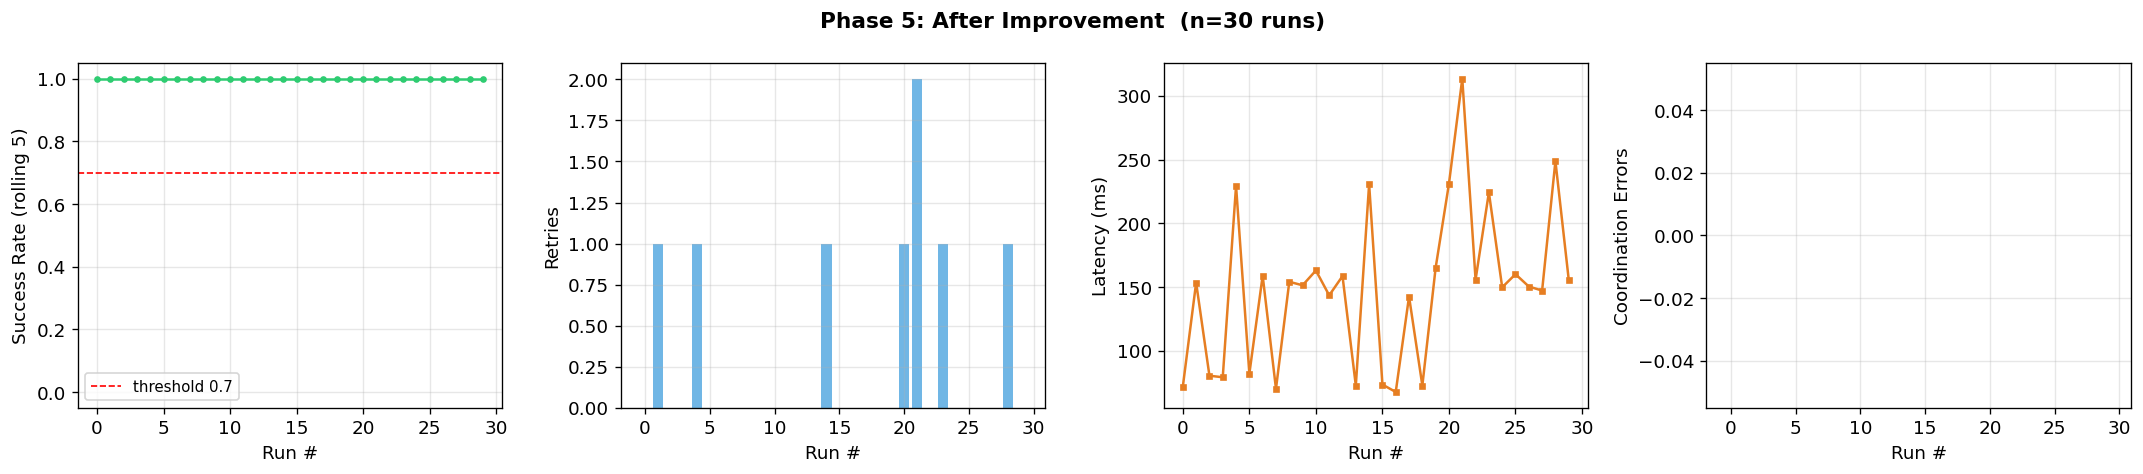

In [14]:
plot_run_metrics(phase5_metrics, title_prefix="Phase 5: After Improvement", alert_lines=True)

### Side-by-Side Comparison

In [15]:
# ─── Numeric comparison ───
s1 = phase1_summary
s5 = phase5_summary

print(f"\n{'Metric':<25s} {'Phase 1 (Broken)':>18s} {'Phase 5 (Fixed)':>18s} {'Change':>12s}")
print(f"{'-'*25} {'-'*18} {'-'*18} {'-'*12}")

rows = [
    ('Success Rate', f"{s1['success_rate']:.1%}", f"{s5['success_rate']:.1%}",
     f"{s5['success_rate'] - s1['success_rate']:+.1%}"),
    ('Avg Retries / Run', f"{s1['avg_retries']:.2f}", f"{s5['avg_retries']:.2f}",
     f"{s5['avg_retries'] - s1['avg_retries']:+.2f}"),
    ('Avg Latency (ms)', f"{s1['avg_latency_ms']:.0f}", f"{s5['avg_latency_ms']:.0f}",
     f"{s5['avg_latency_ms'] - s1['avg_latency_ms']:+.0f}"),
    ('Total Coord Errors', f"{s1['total_coord_errors']}", f"{s5['total_coord_errors']}",
     f"{s5['total_coord_errors'] - s1['total_coord_errors']:+d}"),
    ('Avg Sub-tasks / Run', f"{s1['avg_subtasks']:.1f}", f"{s5['avg_subtasks']:.1f}",
     f"{s5['avg_subtasks'] - s1['avg_subtasks']:+.1f}"),
    ('Alerts Triggered', f"{s1['alerts_triggered']}", f"{s5['alerts_triggered']}",
     f"{s5['alerts_triggered'] - s1['alerts_triggered']:+d}"),
]

for name, v1, v5, delta in rows:
    print(f"{name:<25s} {v1:>18s} {v5:>18s} {delta:>12s}")


Metric                      Phase 1 (Broken)    Phase 5 (Fixed)       Change
------------------------- ------------------ ------------------ ------------
Success Rate                           73.3%             100.0%       +26.7%
Avg Retries / Run                       2.17               0.27        -1.90
Avg Latency (ms)                         489                149         -340
Total Coord Errors                         1                  0           -1
Avg Sub-tasks / Run                      3.1                1.7         -1.5
Alerts Triggered                           0                  0           +0


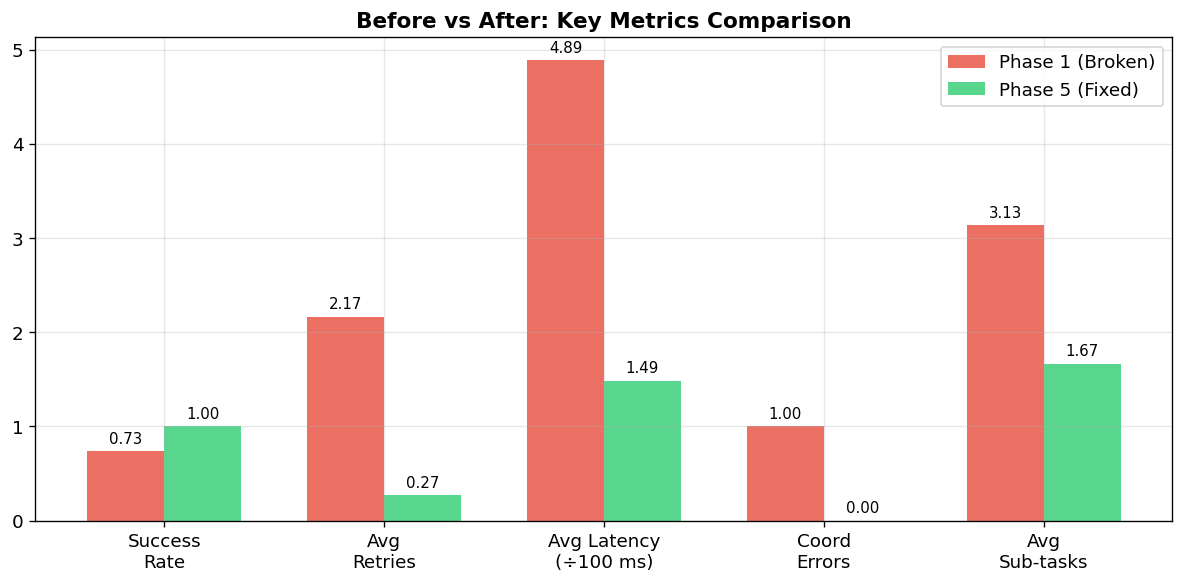

In [16]:
# ─── Bar chart comparison ───
labels = ['Success\nRate', 'Avg\nRetries', 'Avg Latency\n(÷100 ms)', 'Coord\nErrors', 'Avg\nSub-tasks']

# Normalize latency to fit same scale
vals_before = [
    s1['success_rate'],
    s1['avg_retries'],
    s1['avg_latency_ms'] / 100,
    s1['total_coord_errors'],
    s1['avg_subtasks'],
]
vals_after = [
    s5['success_rate'],
    s5['avg_retries'],
    s5['avg_latency_ms'] / 100,
    s5['total_coord_errors'],
    s5['avg_subtasks'],
]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], vals_before, width, label='Phase 1 (Broken)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], vals_after, width, label='Phase 5 (Fixed)', color='#2ecc71', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Before vs After: Key Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend()

# Value labels on bars
for bar_group, vals in [(bars1, vals_before), (bars2, vals_after)]:
    for bar, val in zip(bar_group, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## Summary & Takeaways

We walked through a full **Monitor → Debug → Improve** cycle:

| Phase | Action | Outcome |
|-------|--------|---------|
| 1 | Run without thresholds | Metrics degrade silently — no one notices. |
| 2 | Add alerting rules (`retry_rate > 0.3`, `success_rate < 0.7`) | Alerts fire, degradation is detected. |
| 3 | Debug: correlate sub-task count with failure | Root cause identified: planner over-decomposition. |
| 4 | Human decision rejects AI suggestion (more retries) in favor of simplifying the planner | Correct fix applied. |
| 5 | Re-run improved system | Success rate up, retries and latency down, zero alerts. |

### Key Lessons

1. **Silent degradation is dangerous.** Without thresholds, systems rot unnoticed.  
2. **Symptoms ≠ root cause.** High retries *looked like* a transient-failure problem, but the real issue was coordination complexity from an over-eager planner.  
3. **Human-in-the-loop is critical.** The AI's automatic suggestion (more retries) would have made things worse. A human reviewing diagnostics made the right call.  
4. **Fix the source, not the sink.** Simplifying upstream (planner) is better than compensating downstream (executor retries).